## statring point for generating input files for DALES

#### First let's plot the surface total fluxes 

In [1]:
# metview >= 5.10
import os
os.environ["PATH"] = "/usr/local/apps/ecmwf-toolbox/2025.10.0.0/GNU/8.5/bin:" + os.environ["PATH"]
# import metview as mv
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## directory where to save or look for data
data_dir = "/scratch/paaa/CATRINE"
out_dir = "/perm/paaa/images/quick"

os.makedirs(data_dir, exist_ok=True)
os.makedirs(f"{data_dir}/for_dales", exist_ok=True)

inidate="20220515"
initime="0"
runid = "iyw7"
runids = [
    ("iyw7", "control",              "#e41a1c"),  # red
]

case_study="Cabauw"

if case_study=="Cabauw":
    # Cabauw location
    lon_pt=4.927
    lat_pt=51.971
domain_margin = 1 # 0.5 degrees per side -> 1x1 degrees

experiments = {}

In [2]:
dir_in_dales = '/perm/paaa/Les/Cases/Catrine/Martin/'
input = xr.open_mfdataset(dir_in_dales+'input/les_input_catrine_15_18.nc')
input


<xarray.Dataset> Size: 3MB
Dimensions:              (time: 96, z: 180, zs: 4, lev: 138, lay: 137)
Coordinates:
  * time                 (time) datetime64[ns] 768B 2022-05-15 ... 2022-05-18...
  * z                    (z) float64 1kB 4.0 12.06 20.24 ... 7.073e+03 7.188e+03
  * zs                   (zs) float64 32B -0.035 -0.175 -0.64 -1.945
  * lev                  (lev) int64 1kB 0 1 2 3 4 5 ... 132 133 134 135 136 137
  * lay                  (lay) int64 1kB 0 1 2 3 4 5 ... 131 132 133 134 135 136
Data variables: (12/31)
    thl                  (time, z) float64 138kB dask.array<chunksize=(96, 180), meta=np.ndarray>
    T                    (time, z) float64 138kB dask.array<chunksize=(96, 180), meta=np.ndarray>
    qt                   (time, z) float64 138kB dask.array<chunksize=(96, 180), meta=np.ndarray>
    u                    (time, z) float64 138kB dask.array<chunksize=(96, 180), meta=np.ndarray>
    v                    (time, z) float64 138kB dask.array<chunksize=(96, 180), meta=np.ndarray>
    wls                  (time, z) float64 138kB dask.array<chunksize=(96, 180), meta=np.ndarray>
    ...                   ...
    LH_int               (time) float64 768B dask.array<chunksize=(96,), meta=np.ndarray>
    fco2nee              (time) float64 768B dask.array<chunksize=(96,), meta=np.ndarray>
    fco2gpp              (time) float64 768B dask.array<chunksize=(96,), meta=np.ndarray>
    fco2rec              (time) float64 768B dask.array<chunksize=(96,), meta=np.ndarray>
    h2o_lay              (time, lay) float64 105kB dask.array<chunksize=(96, 137), meta=np.ndarray>
    co2_antrop_emission  (time) float64 768B dask.array<chunksize=(96,), meta=np.ndarray>
Attributes:
    fc:           0.00011487960315944262
    central_lon:  4.927
    central_lat:  51.971
    area:         0.75°×0.75° spatial average
    source:       IFS + (LS)²D
    description:  Generated by (LS)²D (adapted): https://github.com/LS2D & ht...
    reference:    van Stratum et al. (2023). The benefits and challenges of d...

In [3]:
## Surface level for dales input
target_file=f'{data_dir}/for_dales/{runid}_{case_study}_sfc.grib'
if not os.path.exists(target_file):
    print(f"grib not found for {runid} at {case_study} srf. Retrieving from MARS...")
    req_file=f"mars_request_{runid}_{case_study}_sfc"
    req = {
    # "database":"fdb",
    "class":"rd",
    "type":"fc",
    "date":inidate,
    "expver":runid,
    "param":"skt/sp/sshf/slhf/fco2nee/216090",
    "step":"0/3/6/9/12/15/18/21/24",
    "stream":"oper",
    "time":initime,
    "grid":"0.1/0.1",    
    "levtype":"sfc",
    "anoffset":"9",
    "area":f"{lat_pt+domain_margin}/{lon_pt-domain_margin}/{lat_pt-domain_margin}/{lon_pt+domain_margin}",
    "target":f'"{target_file}"',
    }
    
    kv=['{}={}'.format(k, v) for k, v in req.items()]
    kv='retrieve,{}'.format(','.join(kv))
    print(kv)
    f = open(req_file, "w")
    f.write(kv)
    f.close()
    os.system(f"sbatch --mem='32GB' --wrap='mars {req_file}'")
else:
    print(f"grib already exists for {runid} at {case_study} surface.")

grib already exists for iyw7 at Cabauw surface.


In [4]:
## Model level for dales input
target_file=f'{data_dir}/for_dales/{runid}_{case_study}_ml.grib'
if not os.path.exists(target_file):
    print(f"grib not found for {runid} at {case_study} ml. Retrieving from MARS...")
    req_file=f"mars_request_{runid}_{case_study}_ml"
    req = {
    # "database":"fdb",
    "class":"rd",
    "type":"fc",
    "date":inidate,
    "expver":runid,
    "levelist":"1/2/3/4/5/6/7/8/9/10/11/12/13/14/15/16/17/18/19/20/21/22/23/24/25/26/27/28/29/30/31/32/33/34/35/36/37/38/39/40/41/42/43/44/45/46/47/48/49/50/51/52/53/54/55/56/57/58/59/60/61/62/63/64/65/66/67/68/69/70/71/72/73/74/75/76/77/78/79/80/81/82/83/84/85/86/87/88/89/90/91/92/93/94/95/96/97/98/99/100/101/102/103/104/105/106/107/108/109/110/111/112/113/114/115/116/117/118/119/120/121/122/123/124/125/126/127/128/129/130/131/132/133/134/135/136/137",
    "param":"v/u/w/t/q/210061/82/84/86/88/90",
    "step":"0/3/6/9/12/15/18/21/24",
    "stream":"oper",
    "time":initime,
    "grid":"0.1/0.1",    
    "levtype":"ml",
    "anoffset":"9",
    "area":f"{lat_pt+domain_margin}/{lon_pt-domain_margin}/{lat_pt-domain_margin}/{lon_pt+domain_margin}",
    "target":f'"{target_file}"',
    }
    
    kv=['{}={}'.format(k, v) for k, v in req.items()]
    kv='retrieve,{}'.format(','.join(kv))
    print(kv)
    f = open(req_file, "w")
    f.write(kv)
    f.close()
    os.system(f"sbatch --mem='32GB' --wrap='mars {req_file}'")
else:
    print(f"grib already exists for {runid} at {case_study} ml.")

grib already exists for iyw7 at Cabauw ml.


In [5]:
## LNSP for dales input
target_file=f'{data_dir}/for_dales/{runid}_{case_study}_lnsp.grib'
if not os.path.exists(target_file):
    print(f"grib not found for {runid} at {case_study} lnsp. Retrieving from MARS...")
    req_file=f"mars_request_{runid}_{case_study}_lnsp"
    req = {
    # "database":"fdb",
    "class":"rd",
    "type":"fc",
    "date":inidate,
    "expver":runid,
    "levelist":"1",
    "param":"152",
    "step":"0/3/6/9/12/15/18/21/24",
    "stream":"oper",
    "time":initime,
    "grid":"0.1/0.1",    
    "levtype":"ml",
    "anoffset":"9",
    "area":f"{lat_pt+domain_margin}/{lon_pt-domain_margin}/{lat_pt-domain_margin}/{lon_pt+domain_margin}",
    "target":f'"{target_file}"',
    }
    
    kv=['{}={}'.format(k, v) for k, v in req.items()]
    kv='retrieve,{}'.format(','.join(kv))
    print(kv)
    f = open(req_file, "w")
    f.write(kv)
    f.close()
    os.system(f"sbatch --mem='32GB' --wrap='mars {req_file}'")
else:
    print(f"grib already exists for {runid} at {case_study} lnsp.")

grib already exists for iyw7 at Cabauw lnsp.


In [ ]:
# Open surface 
path = f'{data_dir}/for_dales/{runid}_{case_study}_sfc.grib'
srf_experimental = xr.open_dataset(path, engine="cfgrib", backend_kwargs={"filter_by_keys": {"edition": 2}})
srf = xr.open_dataset(path, engine="cfgrib", backend_kwargs={"filter_by_keys": {"edition": 1}})
ds_srf = xr.merge([srf, srf_experimental]).rename({'p216090': 'co2_emiss_tot'})
# Open model levels
path = f'{data_dir}/for_dales/{runid}_{case_study}_ml.grib'
ds_ml = xr.open_dataset(path, engine="cfgrib", backend_kwargs={"filter_by_keys": {"edition": 2}}).rename({
                                                'p82':'dudt_dyn',
                                                'p84':'dvdt_dyn',
                                                'p86':'dtdt_dyn',
                                                'p88':'dqdt_dyn',
                                                'p90':'dco2dt_dyn'})
# open LNSP
path = f'{data_dir}/for_dales/{runid}_{case_study}_lnsp.grib'
lnsp = xr.open_dataset(path, engine="cfgrib", backend_kwargs={"filter_by_keys": {"edition": 2}})
    

In [324]:
def deaccumulate_var(var_int, dt=3600, dim='step', long_name=None, units=None):
    """
    De-accumulate an xarray DataArray or Dataset along a time/step dimension.
    - var_int: xarray.DataArray or xarray.Dataset
    - dt: divisor (seconds)
    - dim: name of the dimension to diff (default 'step')
    - long_name, units: optional replacements for those attributes

    Keeps all attributes from the input except 'GRIB_name'.
    """

    if isinstance(var_int, xr.Dataset):
        return var_int.map(lambda v: deaccumulate_var(v, dt=dt, dim=dim, long_name=long_name, units=units))

    if not isinstance(var_int, xr.DataArray):
        raise TypeError("var_int must be an xarray.DataArray or xarray.Dataset")

    if dim not in var_int.dims:
        raise ValueError(f"Input must have a '{dim}' dimension")

    # compute differences (result has length N-1 along dim)
    diff = var_int.diff(dim=dim) / dt

    # first timestep is assumed accumulation from zero -> divide first by dt
    first = (var_int.isel({dim: 0}) / dt).expand_dims(dim)

    # concat back to original length and restore original coord values
    result = xr.concat([first, diff], dim=dim)
    result = result.assign_coords({dim: var_int[dim].values})

    # preserve attributes except GRIB_name, allow overriding long_name and units
    attrs = dict(var_int.attrs or {})
    attrs.pop('GRIB_name', None)
    if long_name is not None:
        attrs['long_name'] = long_name
    if units is not None:
        attrs['units'] = units
    result.attrs = attrs
    return result


In [325]:
dt = 3600*3 #seconds
ds_srf['slhf'] = deaccumulate_var(ds_srf['slhf'],dt=dt,
                              long_name='Surface latent heat net flux',units='J m**-2 s**-1')
ds_srf['sshf'] = deaccumulate_var(ds_srf['sshf'],dt=dt,
                              long_name='Surface sensible heat net flux',units='J m**-2 s**-1')
ds_srf['co2_emiss_tot'] = deaccumulate_var(ds_srf['co2_emiss_tot'],dt=dt,
                                       long_name='Total CO2 emission flux',units='Kg m**-2 s**-1')
ds_ml['dudt_dyn'] = deaccumulate_var(ds_ml['dudt_dyn'],dt=dt,
                                  long_name='Dynamical tendency zonal wind',units='m s**-2')
ds_ml['dvdt_dyn'] = deaccumulate_var(ds_ml['dvdt_dyn'],dt=dt,
                                  long_name='Dynamical tendency meridional wind',units='m s**-2')
ds_ml['dtdt_dyn'] = deaccumulate_var(ds_ml['dtdt_dyn'],dt=dt,
                                  long_name='Dynamical tendency temperature',units='K s**-1')
ds_ml['dqdt_dyn'] = deaccumulate_var(ds_ml['dqdt_dyn'],dt=dt,
                                  long_name='Dynamical tendency specific humidity',units='kg kg**-1 s**-1')
ds_ml['dco2dt_dyn'] = deaccumulate_var(ds_ml['dco2dt_dyn'],dt=dt,
                                  long_name='Dynamical tendency CO2',units='kg kg**-1 s**-1')




In [371]:
## from hybrid model levels to height
def ml_to_height_levels(
    ds_ml,
    lnsp=None,
    sp=None,
    hlevs=None,
    top_lev=60,
):
    """
    Convert model-level variables to fixed height levels.

    Parameters
    ----------
    ds_ml : xr.Dataset
        Dataset on hybrid model levels with dims (level, step, latitude, longitude)
    lnsp : xr.DataArray, optional
        Log surface pressure with dims (step, latitude, longitude)
    sp : xr.DataArray, optional
        Surface pressure (only used if lnsp is None)
    a, b : array-like, optional
        Hybrid coordinate A and B coefficients for half-levels.
    hlevs : array-like, optional
        Output target height levels [m].
    top_lev : int
        Highest model level index to include.
    g : float
        Acceleration due to gravity.

    Returns
    -------
    xr.Dataset
        Dataset interpolated to fixed height levels.
    """

    # ------------------------------------------------------------------
    # 1. defaults
    # ------------------------------------------------------------------
    # ds_ml = ds_ml.transpose("step", "hybrid", "latitude", "longitude")

    g=9.80665
    if hlevs is None:
        hlevs = np.array([0,20,40,60,80,100,120,140,160,180,200,250,300,350,400,450,500,
                          570,640,710,880,950,1050,1150,1250,1350,1450,1550,1700,1900,2200,
                          2500,2800,3100,3400,3700,4000,4500,5000,5500,6000])

    hlevs = np.asarray(hlevs)

    a= np.array([ 2.000365, 3.102241, 4.666084, 6.827977, 9.746966, 13.605424, 18.608931, 24.985718, 32.985710, 42.879242, 54.955463, 69.520576, 86.895882, 107.415741, 131.425507, 159.279404, 191.338562, 227.968948, 269.539581, 316.420746, 368.982361, 427.592499, 492.616028, 564.413452, 643.339905, 729.744141, 823.967834, 926.344910, 1037.201172, 1156.853638, 1285.610352, 1423.770142, 1571.622925, 1729.448975, 1897.519287, 2076.095947, 2265.431641, 2465.770508, 2677.348145, 2900.391357, 3135.119385, 3381.743652, 3640.468262, 3911.490479, 4194.930664, 4490.817383, 4799.149414, 5119.895020, 5452.990723, 5798.344727, 6156.074219, 6526.946777, 6911.870605, 7311.869141, 7727.412109, 8159.354004, 8608.525391, 9076.400391, 9562.682617, 10065.978516, 10584.631836, 11116.662109, 11660.067383, 12211.547852, 12766.873047, 13324.668945, 13881.331055, 14432.139648, 14975.615234, 15508.256836, 16026.115234, 16527.322266, 17008.789062, 17467.613281, 17901.621094, 18308.433594, 18685.718750, 19031.289062, 19343.511719, 19620.042969, 19859.390625, 20059.931641, 20219.664062, 20337.863281, 20412.308594, 20442.078125, 20425.718750, 20361.816406, 20249.511719, 20087.085938, 19874.025391, 19608.572266, 19290.226562, 18917.460938, 18489.707031, 18006.925781, 17471.839844, 16888.687500, 16262.046875, 15596.695312, 14898.453125, 14173.324219, 13427.769531, 12668.257812, 11901.339844, 11133.304688, 10370.175781, 9617.515625, 8880.453125, 8163.375000, 7470.343750, 6804.421875, 6168.531250, 5564.382812, 4993.796875, 4457.375000, 3955.960938, 3489.234375, 3057.265625, 2659.140625, 2294.242188, 1961.500000, 1659.476562, 1387.546875, 1143.250000, 926.507812, 734.992188, 568.062500, 424.414062, 302.476562, 202.484375, 122.101562, 62.781250, 22.835938, 3.757813, 0.000000, 0.000000 ])
    b = np.array([ 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000007, 0.000024, 0.000059, 0.000112, 0.000199, 0.000340, 0.000562, 0.000890, 0.001353, 0.001992, 0.002857, 0.003971, 0.005378, 0.007133, 0.009261, 0.011806, 0.014816, 0.018318, 0.022355, 0.026964, 0.032176, 0.038026, 0.044548, 0.051773, 0.059728, 0.068448, 0.077958, 0.088286, 0.099462, 0.111505, 0.124448, 0.138313, 0.153125, 0.168910, 0.185689, 0.203491, 0.222333, 0.242244, 0.263242, 0.285354, 0.308598, 0.332939, 0.358254, 0.384363, 0.411125, 0.438391, 0.466003, 0.493800, 0.521619, 0.549301, 0.576692, 0.603648, 0.630036, 0.655736, 0.680643, 0.704669, 0.727739, 0.749797, 0.770798, 0.790717, 0.809536, 0.827256, 0.843881, 0.859432, 0.873929, 0.887408, 0.899900, 0.911448, 0.922096, 0.931881, 0.940860, 0.949064, 0.956550, 0.963352, 0.969513, 0.975078, 0.980072, 0.984542, 0.988500, 0.991984, 0.995003, 0.997630, 1.000000 ])

    # --- Rename vertical coordinate ---
    if "hybrid" not in ds_ml.coords:
        if "level" in ds_ml.coords:
            ds_ml = ds_ml.rename({"level": "hybrid"})
        else:
            raise ValueError("Dataset must have 'level' or 'hybrid' coordinate.")

    # --- Convert a/b to DataArray ---
    nlev = len(a)
    a_da = xr.DataArray(a, dims=["hybrid"], coords={"hybrid": np.arange(nlev)})
    b_da = xr.DataArray(b, dims=["hybrid"], coords={"hybrid": np.arange(nlev)})    

    if lnsp is not None:
        lnsp_matched = lnsp['lnsp'].reindex(latitude=ds_ml.latitude, longitude=ds_ml.longitude, method="nearest")
        p_half = a_da + b_da * np.exp(lnsp_matched)
    elif sp is not None:
        sp_da = sp.expand_dims({"hybrid": nlev})
        p_half = a_da + b_da * sp_da
    else:
        raise ValueError("Provide lnsp or sp.")
    p_half = p_half.transpose("step", "latitude", "longitude","hybrid")


    # --- Mid-level pressure ---
    p_ml = 0.5 * (p_half + p_half.shift(hybrid=1)).isel(hybrid=slice(top_lev-1, None))
    p_ml = p_ml.assign_coords(hybrid=np.arange(top_lev, top_lev + p_ml.sizes["hybrid"]))


    ds_ml = ds_ml.sel(hybrid=p_ml.hybrid)
    ds_ml["p"] = p_ml

    # --- Hydrostatic height ---
    T = ds_ml["t"]
    q = ds_ml["q"]/1000.0
    R = 287.06 * (1 + 0.608 * q)
    rho = p_ml / (R*T)
    dp = p_ml.diff("hybrid")
    dz = dp / rho.isel(hybrid=slice(1,None)) / g
    dz_rev = dz.sortby("hybrid", ascending=False)
    z_accum = dz_rev.cumsum("hybrid").sortby("hybrid")
    h_levels = z_accum

    # --- Output dataset ---
    ds_z = xr.Dataset(coords={"step": ds_ml.step, "latitude": ds_ml.latitude,
                              "longitude": ds_ml.longitude, "height": hlevs})
    for var in ds_ml.data_vars:
        ds_z[var] = xr.full_like(ds_z["height"].broadcast_like(ds_z[["step","latitude","longitude","height"]]),
                                 fill_value=np.nan, dtype=ds_ml[var].dtype)
        ds_z[var].attrs = ds_ml[var].attrs

    # --- Interpolate ---
    for step_i in ds_ml.step:
        for lat_i in ds_ml.latitude:
            for lon_i in ds_ml.longitude:
                it = ds_ml.sel(step=step_i, latitude=lat_i, longitude=lon_i).sel(hybrid=slice(top_lev+1,137))
                z_it = h_levels.sel(step=step_i, latitude=lat_i, longitude=lon_i)
                it2 = it.assign_coords(height=("hybrid", z_it.values)).swap_dims({"hybrid":"height"})
                it2 = it2.interp(height=hlevs, kwargs={"fill_value":"extrapolate"})
                ds_z.loc[dict(step=step_i, latitude=lat_i, longitude=lon_i)] = it2

    ds_z["height"].attrs.update(units="m", long_name="Height above surface")
    return ds_z

In [ ]:
# --- Compute values on height levels ---
ds_z= ml_to_height_levels(ds_ml,lnsp)

In [ ]:
# --- Merge surface and height datasets ---
ds = xr.merge([ds_srf, ds_z])

In [ ]:
# --- Save dataset ---
ds.to_netcdf(f'/perm/paaa/Les/Cases/Catrine/Martin/input/{runid}_les_input_{case_study}_{inidate}.nc')

#### Plotting 

In [30]:
ds.valid_time.values

array(['2022-05-15T00:00:00.000000000', '2022-05-15T03:00:00.000000000',
       '2022-05-15T06:00:00.000000000', '2022-05-15T09:00:00.000000000',
       '2022-05-15T12:00:00.000000000', '2022-05-15T15:00:00.000000000',
       '2022-05-15T18:00:00.000000000', '2022-05-15T21:00:00.000000000',
       '2022-05-16T00:00:00.000000000'], dtype='datetime64[ns]')

In [31]:
ds_file = f'/perm/paaa/Les/Cases/Catrine/Martin/input/{runid}_les_input_{case_study}_{inidate}.nc'
ds = xr.open_mfdataset(ds_file)
if 'step' in ds.dims and 'valid_time' in ds.coords:
    ds = ds.swap_dims({'step': 'valid_time'})
ds

<xarray.Dataset> Size: 9MB
Dimensions:        (valid_time: 9, latitude: 21, longitude: 21, height: 41)
Coordinates:
    number         int64 8B ...
    time           datetime64[ns] 8B ...
    step           (valid_time) timedelta64[ns] 72B 00:00:00 ... 1 days 00:00:00
    surface        float64 8B ...
  * latitude       (latitude) float64 168B 52.97 52.87 52.77 ... 51.07 50.97
  * longitude      (longitude) float64 168B 3.927 4.027 4.127 ... 5.827 5.927
  * valid_time     (valid_time) datetime64[ns] 72B 2022-05-15 ... 2022-05-16
  * height         (height) int64 328B 0 20 40 60 80 ... 4500 5000 5500 6000
Data variables: (12/17)
    skt            (valid_time, latitude, longitude) float32 16kB dask.array<chunksize=(9, 21, 21), meta=np.ndarray>
    sshf           (valid_time, latitude, longitude) float32 16kB dask.array<chunksize=(9, 21, 21), meta=np.ndarray>
    slhf           (valid_time, latitude, longitude) float32 16kB dask.array<chunksize=(9, 21, 21), meta=np.ndarray>
    fco2nee        (valid_time, latitude, longitude) float32 16kB dask.array<chunksize=(9, 21, 21), meta=np.ndarray>
    co2_emiss_tot  (valid_time, latitude, longitude) float32 16kB dask.array<chunksize=(9, 21, 21), meta=np.ndarray>
    w              (valid_time, latitude, longitude, height) float32 651kB dask.array<chunksize=(9, 21, 21, 41), meta=np.ndarray>
    ...             ...
    dtdt_dyn       (valid_time, latitude, longitude, height) float32 651kB dask.array<chunksize=(9, 21, 21, 41), meta=np.ndarray>
    dqdt_dyn       (valid_time, latitude, longitude, height) float32 651kB dask.array<chunksize=(9, 21, 21, 41), meta=np.ndarray>
    dco2dt_dyn     (valid_time, latitude, longitude, height) float32 651kB dask.array<chunksize=(9, 21, 21, 41), meta=np.ndarray>
    u              (valid_time, latitude, longitude, height) float32 651kB dask.array<chunksize=(9, 21, 21, 41), meta=np.ndarray>
    v              (valid_time, latitude, longitude, height) float32 651kB dask.array<chunksize=(9, 21, 21, 41), meta=np.ndarray>
    p              (valid_time, latitude, longitude, height) float64 1MB dask.array<chunksize=(9, 21, 21, 41), meta=np.ndarray>
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-11-26T15:59 GRIB to CDM+CF via cfgrib-0.9.1...

In [386]:
input

<xarray.Dataset> Size: 3MB
Dimensions:              (time: 96, z: 180, zs: 4, lev: 138, lay: 137)
Coordinates:
  * time                 (time) datetime64[ns] 768B 2022-05-15 ... 2022-05-18...
  * z                    (z) float64 1kB 4.0 12.06 20.24 ... 7.073e+03 7.188e+03
  * zs                   (zs) float64 32B -0.035 -0.175 -0.64 -1.945
  * lev                  (lev) int64 1kB 0 1 2 3 4 5 ... 132 133 134 135 136 137
  * lay                  (lay) int64 1kB 0 1 2 3 4 5 ... 131 132 133 134 135 136
Data variables: (12/31)
    thl                  (time, z) float64 138kB dask.array<chunksize=(96, 180), meta=np.ndarray>
    T                    (time, z) float64 138kB dask.array<chunksize=(96, 180), meta=np.ndarray>
    qt                   (time, z) float64 138kB dask.array<chunksize=(96, 180), meta=np.ndarray>
    u                    (time, z) float64 138kB dask.array<chunksize=(96, 180), meta=np.ndarray>
    v                    (time, z) float64 138kB dask.array<chunksize=(96, 180), meta=np.ndarray>
    wls                  (time, z) float64 138kB dask.array<chunksize=(96, 180), meta=np.ndarray>
    ...                   ...
    LH_int               (time) float64 768B dask.array<chunksize=(96,), meta=np.ndarray>
    fco2nee              (time) float64 768B dask.array<chunksize=(96,), meta=np.ndarray>
    fco2gpp              (time) float64 768B dask.array<chunksize=(96,), meta=np.ndarray>
    fco2rec              (time) float64 768B dask.array<chunksize=(96,), meta=np.ndarray>
    h2o_lay              (time, lay) float64 105kB dask.array<chunksize=(96, 137), meta=np.ndarray>
    co2_antrop_emission  (time) float64 768B dask.array<chunksize=(96,), meta=np.ndarray>
Attributes:
    fc:           0.00011487960315944262
    central_lon:  4.927
    central_lat:  51.971
    area:         0.75°×0.75° spatial average
    source:       IFS + (LS)²D
    description:  Generated by (LS)²D (adapted): https://github.com/LS2D & ht...
    reference:    van Stratum et al. (2023). The benefits and challenges of d...

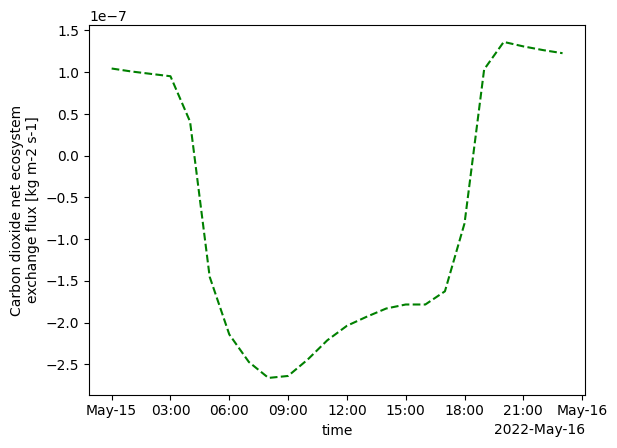

In [23]:
input['fco2nee'].sel(time='2022-05-15').plot(c='g',ls='--',label='old input')


In [38]:
ds

<xarray.Dataset> Size: 9MB
Dimensions:        (valid_time: 9, latitude: 21, longitude: 21, height: 41)
Coordinates:
    number         int64 8B ...
    time           datetime64[ns] 8B ...
    step           (valid_time) timedelta64[ns] 72B 00:00:00 ... 1 days 00:00:00
    surface        float64 8B ...
  * latitude       (latitude) float64 168B 52.97 52.87 52.77 ... 51.07 50.97
  * longitude      (longitude) float64 168B 3.927 4.027 4.127 ... 5.827 5.927
  * valid_time     (valid_time) datetime64[ns] 72B 2022-05-15 ... 2022-05-16
  * height         (height) int64 328B 0 20 40 60 80 ... 4500 5000 5500 6000
Data variables: (12/17)
    skt            (valid_time, latitude, longitude) float32 16kB dask.array<chunksize=(9, 21, 21), meta=np.ndarray>
    sshf           (valid_time, latitude, longitude) float32 16kB dask.array<chunksize=(9, 21, 21), meta=np.ndarray>
    slhf           (valid_time, latitude, longitude) float32 16kB dask.array<chunksize=(9, 21, 21), meta=np.ndarray>
    fco2nee        (valid_time, latitude, longitude) float32 16kB dask.array<chunksize=(9, 21, 21), meta=np.ndarray>
    co2_emiss_tot  (valid_time, latitude, longitude) float32 16kB dask.array<chunksize=(9, 21, 21), meta=np.ndarray>
    w              (valid_time, latitude, longitude, height) float32 651kB dask.array<chunksize=(9, 21, 21, 41), meta=np.ndarray>
    ...             ...
    dtdt_dyn       (valid_time, latitude, longitude, height) float32 651kB dask.array<chunksize=(9, 21, 21, 41), meta=np.ndarray>
    dqdt_dyn       (valid_time, latitude, longitude, height) float32 651kB dask.array<chunksize=(9, 21, 21, 41), meta=np.ndarray>
    dco2dt_dyn     (valid_time, latitude, longitude, height) float32 651kB dask.array<chunksize=(9, 21, 21, 41), meta=np.ndarray>
    u              (valid_time, latitude, longitude, height) float32 651kB dask.array<chunksize=(9, 21, 21, 41), meta=np.ndarray>
    v              (valid_time, latitude, longitude, height) float32 651kB dask.array<chunksize=(9, 21, 21, 41), meta=np.ndarray>
    p              (valid_time, latitude, longitude, height) float64 1MB dask.array<chunksize=(9, 21, 21, 41), meta=np.ndarray>
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-11-26T15:59 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
plt.figure()
d


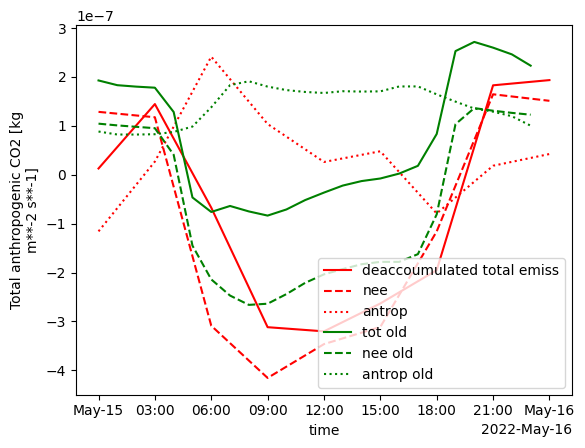

In [36]:
plt.figure()
(-ds['co2_emiss_tot']).sel(latitude=lat_pt, longitude=lon_pt, method='nearest').plot(c='r',label='deaccoumulated total emiss')
(-ds['fco2nee']).sel(latitude=lat_pt, longitude=lon_pt, method='nearest').plot(ls='--',c='r',label='nee')
(-ds['co2_emiss_tot']+ds['fco2nee']).sel(latitude=lat_pt, longitude=lon_pt, method='nearest').plot(ls=':',c='r',label='antrop')

(input['fco2nee']+input['co2_antrop_emission']).sel(time='2022-05-15').plot(c='g',ls='-',label='tot old')
input['fco2nee'].sel(time='2022-05-15').plot(c='g',ls='--',label='nee old')
input['co2_antrop_emission'].sel(time='2022-05-15').plot(c='g',ls=':',label='antrop old')
plt.legend()

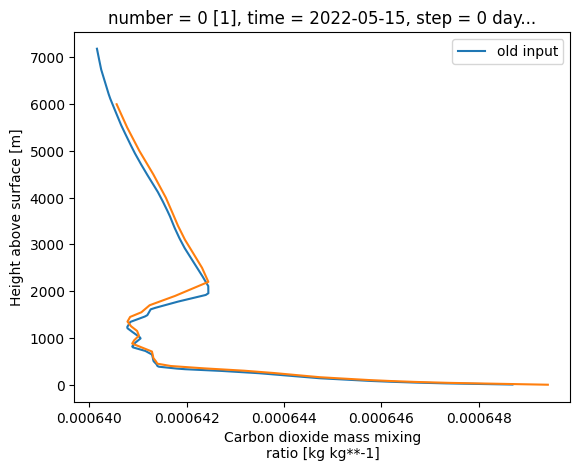

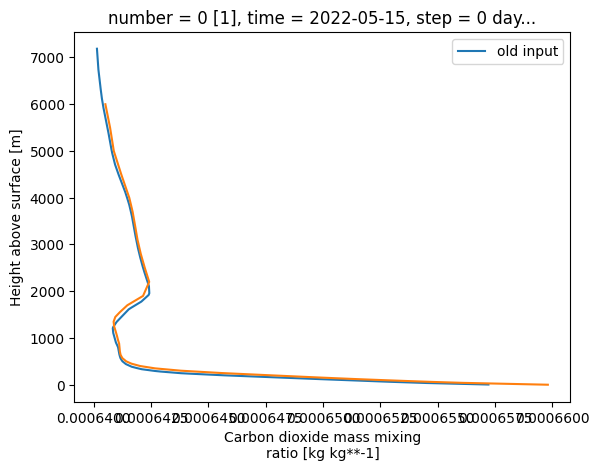

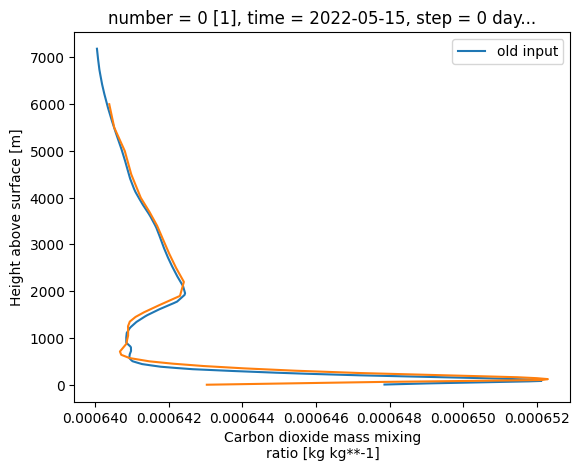

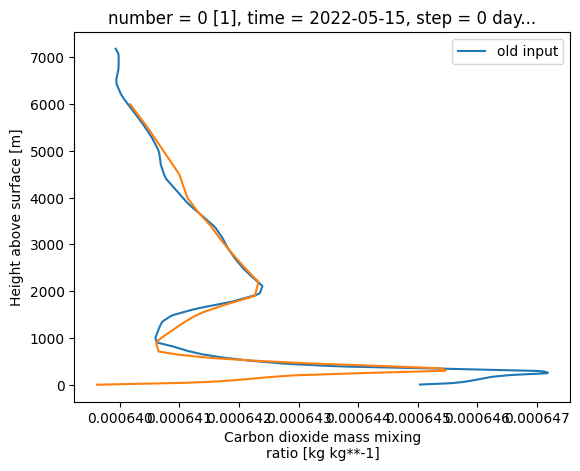

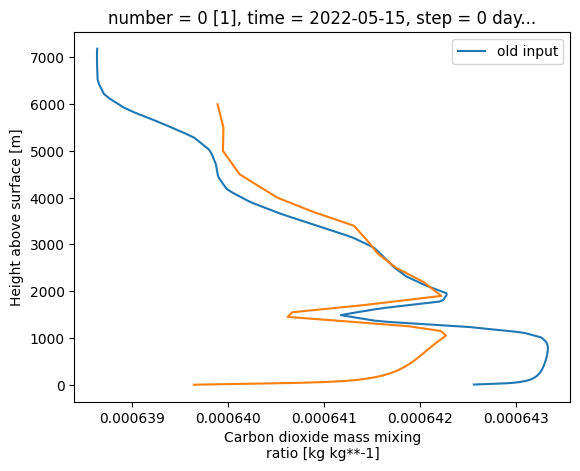

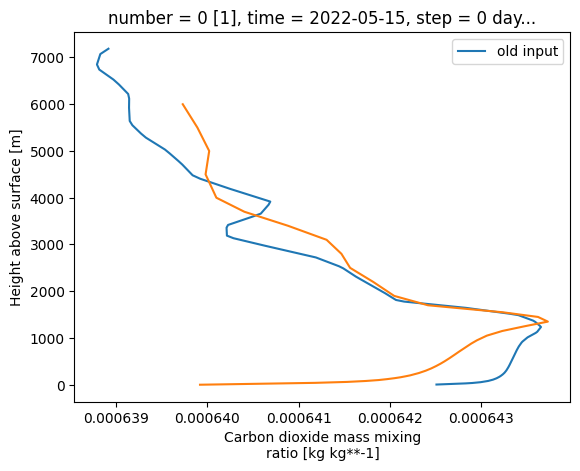

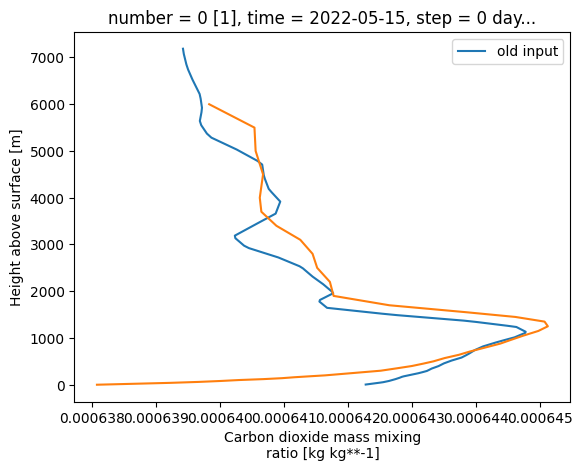

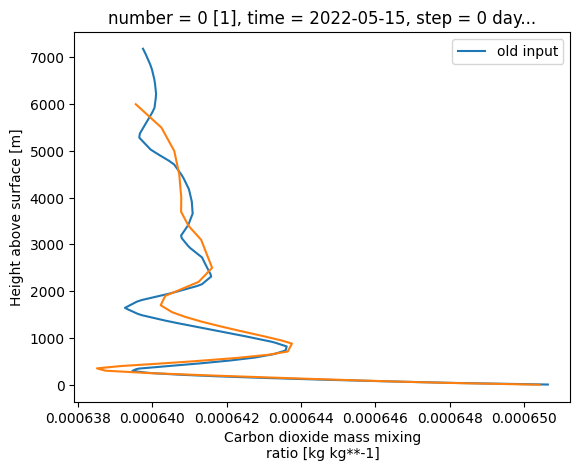

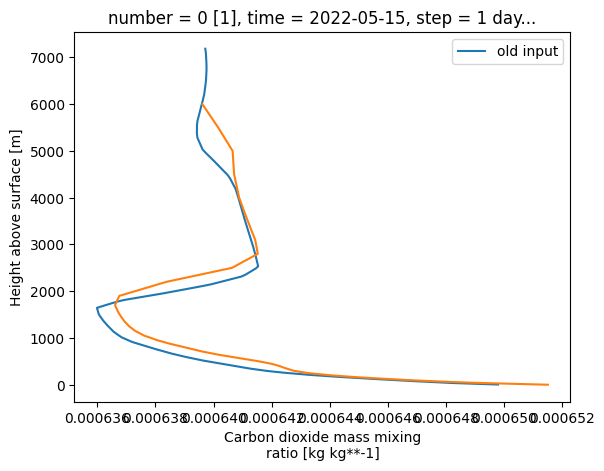

In [ ]:
time ='2022-05-15T21'
for time in ds['valid_time']:

    plt.figure()
    input['co2'].sel(time=time).plot(y='z',label='old input')
    ds['co2'].sel(latitude=lat_pt,longitude=lon_pt,method='nearest').sel(valid_time=time).plot(y='height',label)
    plt.legend()

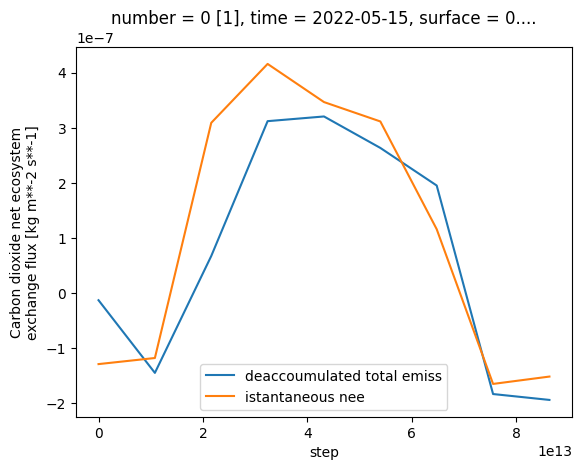

In [378]:
plt.figure()
ds['co2_emiss_tot'].sel(latitude=lat_pt, longitude=lon_pt, method='nearest').plot(label='deaccoumulated total emiss')
ds['fco2nee'].sel(latitude=lat_pt, longitude=lon_pt, method='nearest').plot(label='istantaneous nee')
plt.legend()

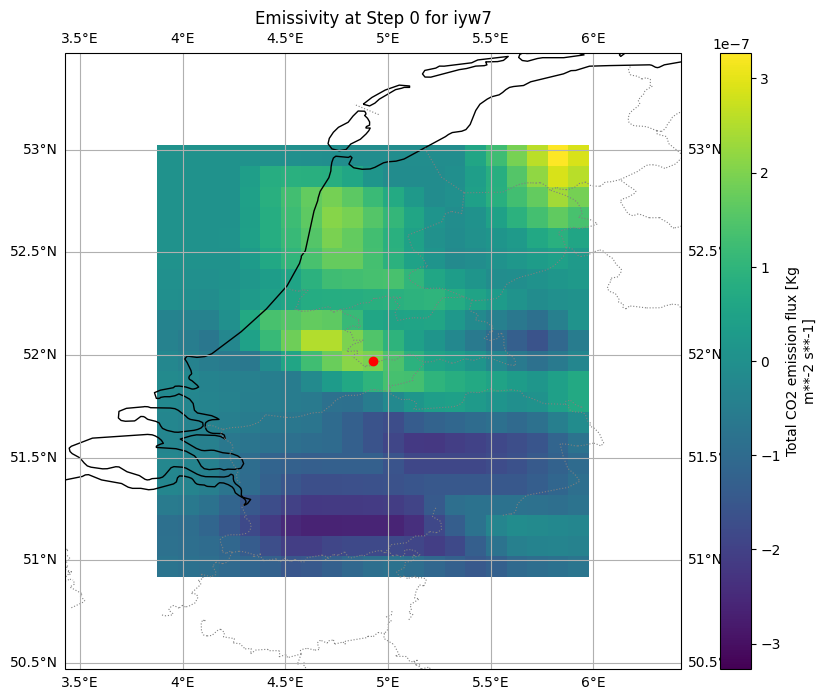

In [ ]:
# Assuming experiments["emiss"][runid] is a DataArray
emiss_data = ds_srf['co2_emiss_tot'].isel(step=6)  # Select step 0

plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
emiss_data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='viridis')

# increase lat/lon min/max around Cabauw
buffer_deg = 1.5  # increase this to zoom out more (degrees)
lon_min = lon_pt - buffer_deg
lon_max = lon_pt + buffer_deg
lat_min = lat_pt - buffer_deg
lat_max = lat_pt + buffer_deg
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add coastlines and gridlines
ax.coastlines(resolution='10m')
ax.gridlines(draw_labels=True)
# Add state/province borders (admin-1) as dotted lines
states = cfeature.NaturalEarthFeature(category='cultural',
                                      name='admin_1_states_provinces_lines',
                                      scale='10m',
                                      facecolor='none')
ax.add_feature(states, edgecolor='gray', linestyle=':', linewidth=0.8)


ax.plot(lon_pt, lat_pt, marker='o', color='red', markersize=6, transform=ccrs.PlateCarree(), zorder=5)


plt.title(f'Emissivity at Step 0 for {runid}')
plt.show()